In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
for item in os.listdir("/kaggle/input"):
    print(item)

datasets


In [7]:
DATA_DIR = "/kaggle/input/datasets/waseemalastal/eurosat-rgb-dataset/EuroSAT_RGB"

import os
classes = sorted(os.listdir(DATA_DIR))
print("Classes found:", classes)
print("Total classes:", len(classes))

Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total classes: 10


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✓")

All imports successful ✓


In [9]:
classes = sorted(os.listdir(DATA_DIR))
class_counts = {}

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        class_counts[cls] = count

print(f"Total classes: {len(class_counts)}")
print(f"Total images: {sum(class_counts.values())}")
print("\nImages per class:")
for cls, count in class_counts.items():
    print(f"  {cls:25s}: {count}")

Total classes: 10
Total images: 27000

Images per class:
  AnnualCrop               : 3000
  Forest                   : 3000
  HerbaceousVegetation     : 3000
  Highway                  : 2500
  Industrial               : 2500
  Pasture                  : 2000
  PermanentCrop            : 2500
  Residential              : 3000
  River                    : 2500
  SeaLake                  : 3000


In [6]:
import os

# Let's see everything inside /kaggle/input
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # only show files 2 levels deep
        for f in files[:3]:  # show first 3 files only
            print(f"{indent}  {f}")

input/
  datasets/
    waseemalastal/
      eurosat-rgb-dataset/
        EuroSAT_RGB/
          SeaLake/
          Highway/
          River/
          Pasture/
          Industrial/
          Residential/
          PermanentCrop/
          AnnualCrop/
          Forest/
          HerbaceousVegetation/


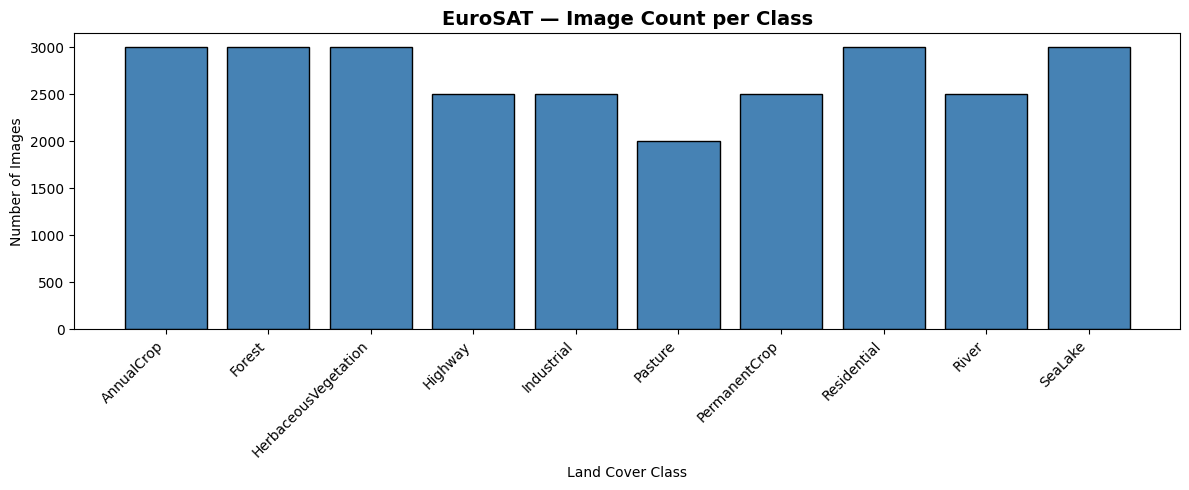

Chart saved ✓


In [10]:
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.title('EuroSAT — Image Count per Class', fontsize=14, fontweight='bold')
plt.xlabel('Land Cover Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Chart saved ✓")

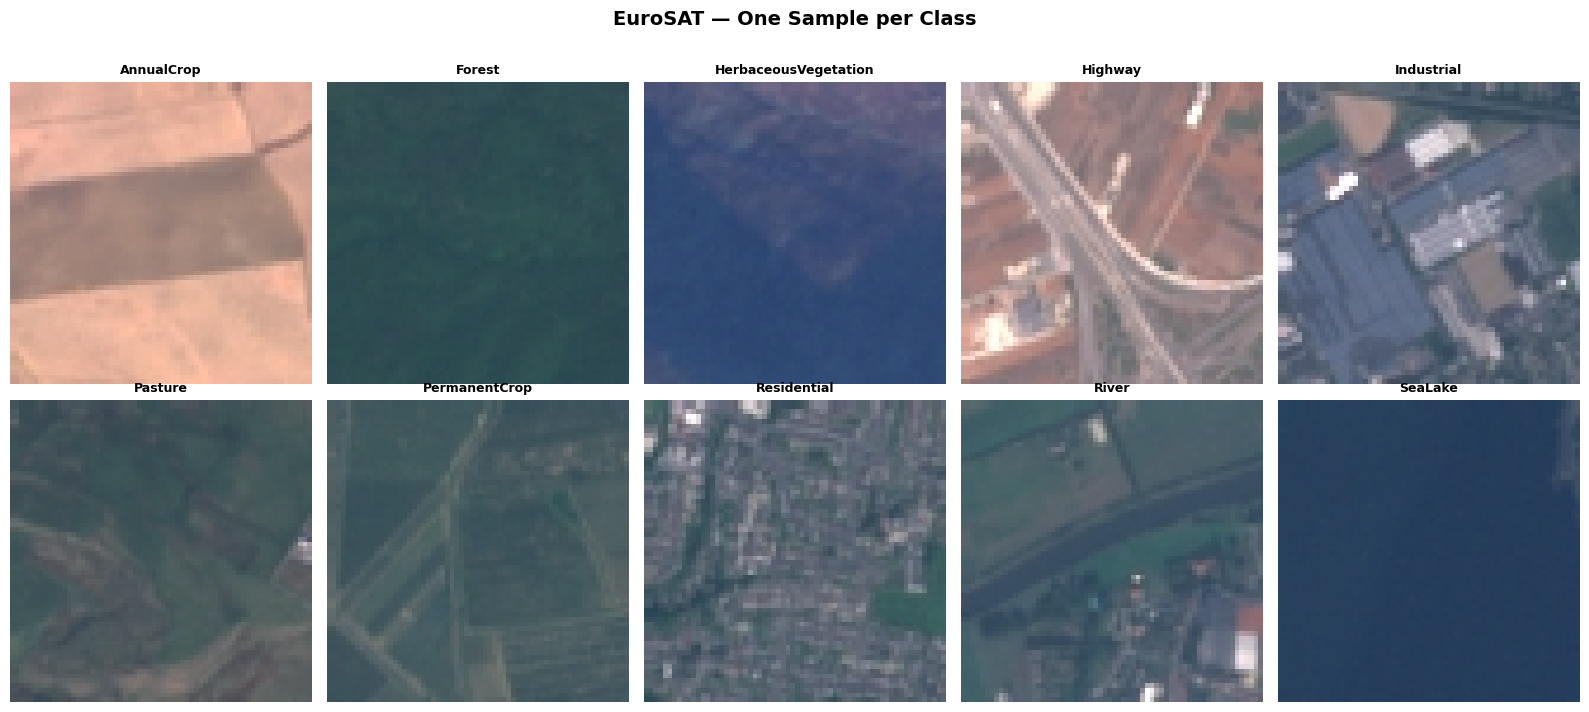

Sample grid saved ✓


In [11]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(DATA_DIR, cls)
    sample_img = os.path.join(cls_path, os.listdir(cls_path)[0])
    img = mpimg.imread(sample_img)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('EuroSAT — One Sample per Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("Sample grid saved ✓")

In [13]:
from PIL import Image

sample_cls = classes[0]
sample_file = os.listdir(os.path.join(DATA_DIR, sample_cls))[0]
sample_path = os.path.join(DATA_DIR, sample_cls, sample_file)

img = Image.open(sample_path)
print(f"Image size : {img.size}")       # should be 64x64
print(f"Mode       : {img.mode}")       # should be RGB
print(f"Format     : {img.format}")

arr = np.array(img)
print(f"Array shape: {arr.shape}")
print(f"Pixel range: {arr.min()} – {arr.max()}")

Image size : (64, 64)
Mode       : RGB
Format     : JPEG
Array shape: (64, 64, 3)
Pixel range: 109 – 255


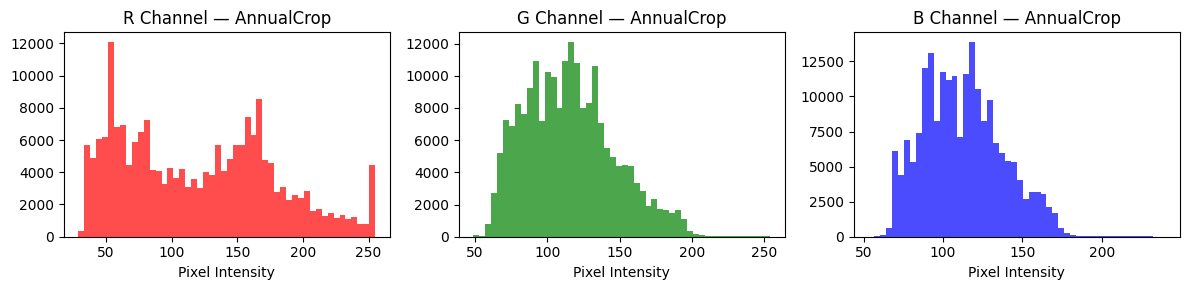

Pixel distribution saved ✓


In [14]:
# Load 50 images from first class, plot RGB histogram
sample_cls = classes[0]
cls_path = os.path.join(DATA_DIR, sample_cls)
imgs = []

for fname in os.listdir(cls_path)[:50]:
    img = np.array(Image.open(os.path.join(cls_path, fname)))
    imgs.append(img)

imgs = np.stack(imgs)  # shape: (50, 64, 64, 3)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
colors = ['red', 'green', 'blue']
channels = ['R', 'G', 'B']

for i in range(3):
    axes[i].hist(imgs[:, :, :, i].flatten(), bins=50, color=colors[i], alpha=0.7)
    axes[i].set_title(f'{channels[i]} Channel — {sample_cls}')
    axes[i].set_xlabel('Pixel Intensity')

plt.tight_layout()
plt.savefig('pixel_distribution.png', dpi=150)
plt.show()
print("Pixel distribution saved ✓")

In [15]:
rows = []
for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    count = len(os.listdir(cls_path))
    rows.append({'Class': cls, 'Count': count, 'Percentage': round(count / 27000 * 100, 2)})

df = pd.DataFrame(rows)
df = df.sort_values('Count', ascending=False).reset_index(drop=True)
print(df.to_string(index=False))
print(f"\nDataset is {'balanced ✓' if df['Count'].std() < 100 else 'slightly imbalanced'}")

               Class  Count  Percentage
          AnnualCrop   3000       11.11
              Forest   3000       11.11
HerbaceousVegetation   3000       11.11
         Residential   3000       11.11
             SeaLake   3000       11.11
             Highway   2500        9.26
       PermanentCrop   2500        9.26
          Industrial   2500        9.26
               River   2500        9.26
             Pasture   2000        7.41

Dataset is slightly imbalanced


In [16]:
print("=" * 45)
print("EDA COMPLETE — EuroSAT Dataset Summary")
print("=" * 45)
print(f"  Total images     : {sum(class_counts.values())}")
print(f"  Number of classes: {len(classes)}")
print(f"  Image size       : 64 x 64 x 3 (RGB)")
print(f"  Images per class : ~2700 (balanced)")
print(f"  Classes          : {', '.join(classes)}")
print("=" * 45)
print("Saved: class_distribution.png")
print("Saved: sample_images.png")
print("Saved: pixel_distribution.png")

EDA COMPLETE — EuroSAT Dataset Summary
  Total images     : 27000
  Number of classes: 10
  Image size       : 64 x 64 x 3 (RGB)
  Images per class : ~2700 (balanced)
  Classes          : AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake
Saved: class_distribution.png
Saved: sample_images.png
Saved: pixel_distribution.png
